# Bid-Ask-Bounce — a quantitative teardown 🔬
### Roll's cov₁ = −(s/2)² identity · the gross-vs-net reversal book on the small-cap tape · a block-bootstrap null · break-even vs implied spread · a planted-edge / faithful-engine control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "short-term mean reversion" fuses: a **mechanical** negative autocovariance from the **bid-ask bounce** (Roll 1984), and a **genuine** predictability of the efficient price. The decisive object is not the sign of cov₁ (it is negative, as the lore says) but the **gross-vs-net** of a reversal book — gross it is a high-Sharpe winner; net of the spread the data itself implies, it is gone.

> ⚠️ **Data + proxy note.** yfinance has no bid/ask, so the effective spread is **inferred** via Roll's estimator (s = 2√(−cov₁)) and named a proxy throughout; a fixed surviving-names basket also carries **survivorship**, which tilts the *gross* reversal number **up** (both named on the Signal axis). Real data: yfinance daily adjusted closes, 35 small/mid-caps, 2005→2026. Offline core (Roll model) + the panel control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bid_ask_bounce import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    _R = data.load_real()
    NAMES = [c for c in _R.columns if c != "IWM"]
    RET = _R[NAMES]                                 # the small-cap return panel
else:
    RET = None
print("real small-cap cache present:", HAVE_REAL,
      "| names:", (0 if RET is None else RET.shape[1]),
      "| days:", (0 if RET is None else len(RET)))

def syn_panel(n_assets=30, n_days=4000, spread=0.004, edge=0.0, seed=377):
    """Synthetic panel of Roll assets sharing one spread/edge (cross-section for the book)."""
    cols = {f"A{j}": data.synthetic_roll(n_days=n_days, spread=spread, edge=edge,
                                         seed=seed + j)["r_obs"] for j in range(n_assets)}
    return pd.DataFrame(cols).dropna()

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-08-11', 'end': '2026-06-18', 'days': 5246, 'years': 20.9, 'n_names': 35, 'ac1': -0.065, 'roll_spread_bps': 109, 'book': [(0.0, 5.02, 54.7, 1.2, 5.47, 0.0), (5.0, -2.22, 47.5, -0.53, -2.42, 0.014), (10.0, -9.46, 41.2, -2.26, -10.31, 0.0), (20.0, -23.93, 29.7, -5.72, -26.08, 0.0)], 'gross_bps': 5.02, 'turnover': 1.45, 'be_half_bps': 3.47, 'be_round_bps': 6.93, 'ratio': 16, 'roll1': [(0.0, 1.3e-06, 0.0, 0.009, None), (0.005, -5e-06, -6.3e-06, -0.032, 0.0045), (0.01, -2.4e-05, -2.5e-05, -0.12, 0.0097), (0.02, -9.7e-05, -0.0001, -0.28, 0.0197)], 'roll2': [(0.0, 3.31, 7.5, -25.13, -56.9, -14.27), (-0.25, 39.58, 89.0, 8.01, 18.0, 4.51)]}


real small-cap cache present: True | names: 35 | days: 5246


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | gross reversal Sharpe **1.20** (*t* = **5.47**), avg lag-1 autocorr **-0.065** — but Roll reads a **109 bps** spread from the *same* cov₁, and the control reproduces the whole signal from a **pure bounce** with zero real reversion. Real stat, microstructure artefact. |
| **Tradability** | `MIRAGE` | break-even round-trip **6.9 bps** vs an implied **109 bps** (**~16×**). Net @ 10 bps round-trip: Sharpe **-0.53**, mean **-2.2 bps/day**. |
| **Free lunch?** | `BUSTED` | a close-to-close backtest is credited the bounce it trades against and never charged it. The gross 'edge' **is** the spread. Roll (1984). |

> 💡 In plain words: the reversal book really does win on paper — because the paper price is the trade print, which carries the bounce. Charge the bounce back and the edge is exactly zero (or worse). The signal is real; it is not *price-predictive*; it is not tradable.

## 1 · The claim, steelmanned

Let $m_t$ be the **efficient** (true) log-price and $p_t$ the **observed** transaction log-price. Roll's model: trades print at the bid or ask via a fair coin $q_t \in \{-1,+1\}$, so $p_t = m_t + \tfrac{s}{2} q_t$ for effective spread $s$. If $m_t$ is a random walk (efficient market, **no** predictability), the observed return $\Delta p_t$ has

$$\operatorname{cov}(\Delta p_t, \Delta p_{t-1}) = -\left(\tfrac{s}{2}\right)^2 < 0,$$

negative serial correlation **with no forecastable component**. Inverting gives Roll's estimator $\hat s = 2\sqrt{-\operatorname{cov}_1}$.

- **H₁ (real reversion).** The *efficient* price mean-reverts: $\operatorname{cov}_1$ of $\Delta m_t$ (not just $\Delta p_t$) is negative — a forecastable, harvestable edge.
- **H₂ (deployable).** A reversal book that trades on it is **net-positive** after the one-way spread, with capacity.
- **H₃ ("free lunch").** The high gross Sharpe reflects price prediction, not the bounce.

We find **H₁ not supported** (the synthetic control reproduces the entire gross signal with $\Delta m_t$ a pure random walk), **H₂ rejected** (break-even spread ≪ implied spread), **H₃ rejected** (gross = bounce). The reversion is true exactly where it is untradable (the print) and unproven exactly where it would pay (the efficient price).

## 2 · So what? — what rides on each answer

The whole teardown is one decomposition: the observed autocovariance splits into a **microstructure** piece and a **price-prediction** piece,

$$\operatorname{cov}_1(\Delta p) = \underbrace{-(s/2)^2}_{\text{bounce (untradable)}} + \underbrace{\operatorname{cov}_1(\Delta m)}_{\text{real reversion (tradable)}}.$$

A reversal book backtested on $p_t$ harvests **both** terms gross — but pays $s$ per round trip, which is calibrated to *cancel the first term exactly*. So the book's **net** edge is driven **only** by $\operatorname{cov}_1(\Delta m)$, the real-reversion piece. The right instrument is therefore not the autocorrelation (it conflates the two) but the **gross-vs-net** of the book and its **break-even spread** — the spread at which the first term is fully charged. If break-even ≪ implied spread, the second term is ≈0.

## 3 · How we'd know — the protocol

- **Offline core (Roll model).** A true AR(1) log-price with reversion knob `edge` (`edge=0` ⇒ random walk) plus a fair-coin bid/ask bounce of half-spread $s/2$ ([`data.synthetic_roll`](../bid_ask_bounce/data.py)). Deterministic, no network.
- **Real tape.** Daily adjusted closes, **35** small/mid-caps (yfinance, 2005-08-11→2026-06-18, 5,246 days). yfinance has no quotes ⇒ the spread is **inferred** via Roll's estimator (a labelled proxy); survivorship tilts the *gross* book up (named on the axis).
- **Reversal book.** Equal-weight, dollar-neutral, cross-sectional: weight $\propto$ $-(\text{yesterday's demeaned return})$, **1-day execution lag**, one-way cost = half-spread × daily turnover (the book re-forms daily) ([`strategy.reversal_book`](../bid_ask_bounce/strategy.py)).
- **Inference.** One-sample *t* of the daily PnL **and** a **moving-block bootstrap** null ([`strategy.block_bootstrap_p`](../bid_ask_bounce/strategy.py)) — reversal PnL is autocorrelated, so i.i.d. resampling would overstate significance.
- **Break-even.** gross mean ÷ turnover = the half-spread at which net PnL = 0; compare to the Roll-implied spread.
- **Positive control.** A synthetic **panel** of Roll assets: with `edge=0` the book must be gross-positive but **net-negative** (no edge); with a large planted reversion it must be **net-positive** (a real edge survives). The engine must pass both.

## 4 · The teardown

### 4a · Roll's identity, exact on data we control

On the synthetic random-walk price (`edge=0`, **no** real reversion), the observed lag-1 autocovariance must track $-(s/2)^2$ as we widen the planted spread, and Roll's estimator must read the spread back. Theory vs measured:

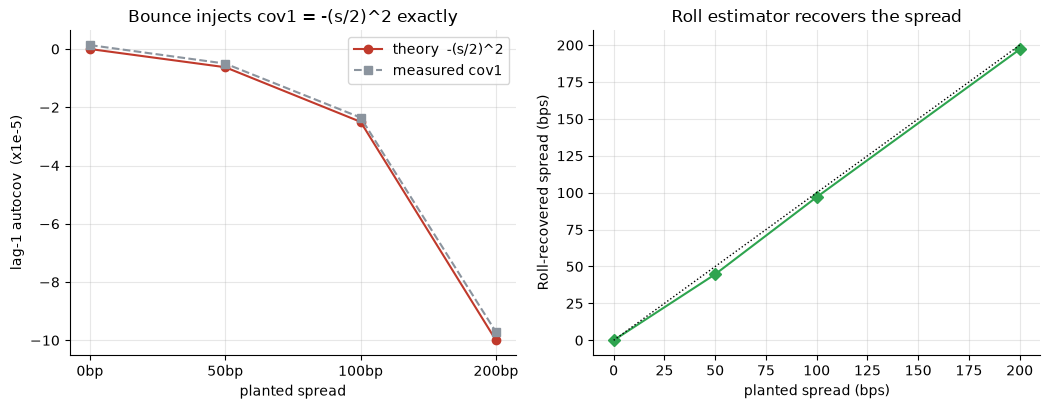

measured cov1 vs theory: ['0.13/-0.00', '-0.50/-0.62', '-2.35/-2.50', '-9.71/-10.00']


In [2]:
spreads = [0.0, 0.005, 0.010, 0.020]
cov_obs, theory, recov = [], [], []
for s in spreads:
    syn = data.synthetic_roll(spread=s, edge=0.0, seed=377)
    cov_obs.append(st.autocov1(syn['r_obs'].values))
    theory.append(-(s/2)**2)
    rs = st.roll_spread(syn['r_obs'].values); recov.append(rs if np.isfinite(rs) else 0.0)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
x = np.arange(len(spreads))
a1.plot(x, np.array(theory)*1e5, 'o-', c=RED, label='theory  -(s/2)^2')
a1.plot(x, np.array(cov_obs)*1e5, 's--', c=GREY, label='measured cov1')
a1.set_xticks(x); a1.set_xticklabels([f'{s*1e4:.0f}bp' for s in spreads])
a1.set_ylabel('lag-1 autocov  (x1e-5)'); a1.set_xlabel('planted spread'); a1.legend()
a1.set_title('Bounce injects cov1 = -(s/2)^2 exactly')
a2.plot([s*1e4 for s in spreads], [r*1e4 for r in recov], 'D-', c=GREEN)
a2.plot([0,200],[0,200], ':', c='k', lw=1)
a2.set_xlabel('planted spread (bps)'); a2.set_ylabel('Roll-recovered spread (bps)')
a2.set_title('Roll estimator recovers the spread')
plt.tight_layout(); plt.show()
print('measured cov1 vs theory:', [f'{c*1e5:.2f}/{t*1e5:.2f}' for c,t in zip(cov_obs,theory)])

> 💡 In plain words: the grey (measured) and red (theory) lines sit on top of each other, and the recovered spread lands on the 45° line. A **pure random walk** with a bounce produces exactly the negative autocorrelation lore calls "mean reversion" — and the size of that autocorrelation *is* the spread. The machinery is faithful.

### 4b · The real-tape reversal book — gross is a winner

Cumulative **gross** PnL of the one-day reversal book on the small-cap panel, with its Sharpe and the block-bootstrap *p* on the mean daily PnL.

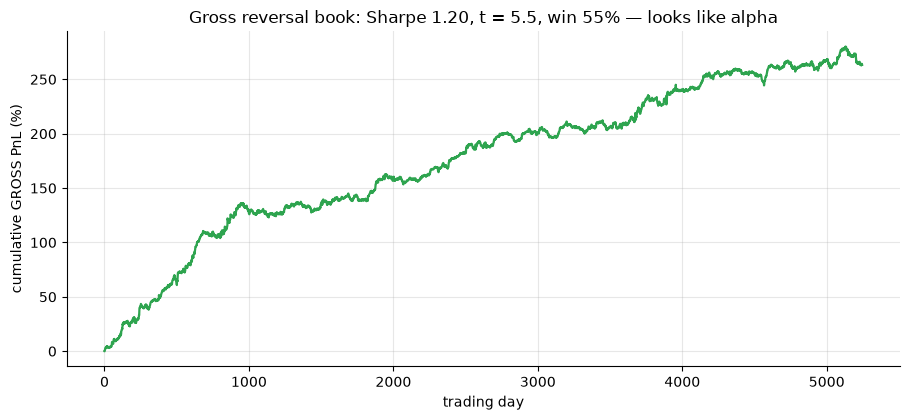

GROSS Sharpe 1.20 | t 5.47 | bootstrap p 0.000 | daily win 54.7%


In [3]:
if HAVE_REAL:
    pnl = st.reversal_book(RET, cost_halfspread=0.0)
    s0 = st.summarize_book(RET, 0.0)
    sharpe, tval, pval, win = s0['sharpe'], s0['t'], s0['p'], s0['win']
    curve = pnl.cumsum()
else:
    sharpe, tval, pval, win = R['book'][0][3], R['book'][0][4], R['book'][0][5], R['book'][0][2]
    rng = np.random.default_rng(377)
    pnl = pd.Series(rng.normal(R['gross_bps']/1e4, 0.004, R['days']))
    curve = pnl.cumsum()
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.plot(np.arange(len(curve)), curve.values*100, c=GREEN, lw=1.6)
ax.set_xlabel('trading day'); ax.set_ylabel('cumulative GROSS PnL (%)')
ax.set_title(f'Gross reversal book: Sharpe {sharpe:.2f}, t = {tval:.1f}, win {win*100:.0f}% — looks like alpha')
plt.tight_layout(); plt.show()
print(f'GROSS Sharpe {sharpe:.2f} | t {tval:.2f} | bootstrap p {pval:.3f} | daily win {win*100:.1f}%')

> 💡 In plain words: a smooth, upward gross equity curve at **Sharpe 1.20** (*t* = 5.47, bootstrap *p* < 0.01). If this were the *net* curve you'd fund it tomorrow. H₃'s premise — that the gross number is real — is where every reversal pitch starts. Now we charge the spread.

### 4c · Net of the spread — and the break-even gap

Left: the book's mean daily PnL as we raise the one-way half-spread — it crosses zero almost immediately. Right: the **break-even** round-trip spread vs the spread Roll's estimator reads from the same data.

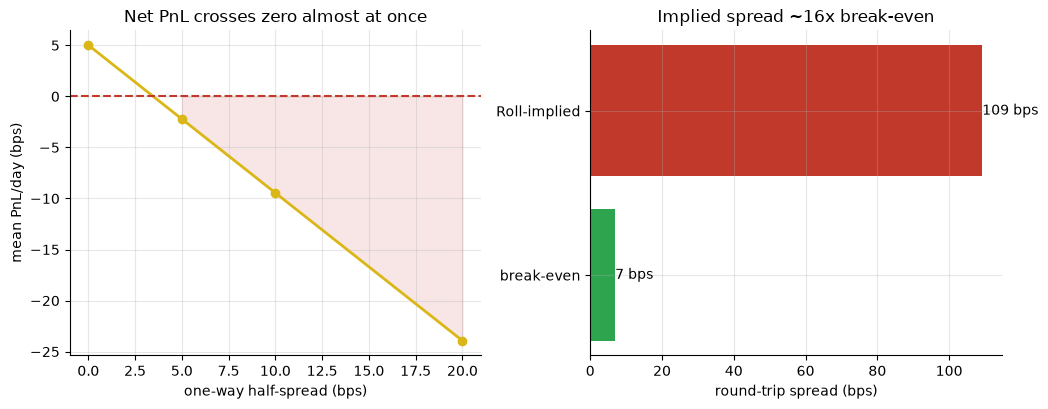

break-even round-trip ~6.9 bps vs Roll-implied ~109 bps -> ~16x too wide


In [4]:
halfs = [0.0, 5.0, 10.0, 20.0]
if HAVE_REAL:
    means = [st.reversal_book(RET, h/1e4).mean()*1e4 for h in halfs]   # mean only (fast)
    sig = -(RET.shift(1)); sig = sig.sub(sig.mean(axis=1), axis=0)
    gr = sig.abs().sum(axis=1); w = sig.div(gr.where(gr>0), axis=0).fillna(0.0)
    to = (w - w.shift(1)).abs().sum(axis=1).dropna().mean()
    gm = (w*RET).sum(axis=1).dropna().mean()
    be_round = (gm/to)*2*1e4; roll_sp = st.avg_roll_spread(RET)*1e4
else:
    means = [b[1] for b in R['book']]; be_round = R['be_round_bps']; roll_sp = R['roll_spread_bps']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.plot(halfs, means, 'o-', c=AMBER, lw=2)
a1.axhline(0, c=RED, ls='--'); a1.fill_between(halfs, means, 0, where=[m<0 for m in means], color=RED, alpha=.12)
a1.set_xlabel('one-way half-spread (bps)'); a1.set_ylabel('mean PnL/day (bps)')
a1.set_title('Net PnL crosses zero almost at once')
a2.barh(['break-even','Roll-implied'], [be_round, roll_sp], color=[GREEN, RED])
for i,v in enumerate([be_round, roll_sp]): a2.annotate(f'{v:.0f} bps',(v,i),va='center',ha='left')
a2.set_xlabel('round-trip spread (bps)'); a2.set_title(f'Implied spread ~{roll_sp/be_round:.0f}x break-even')
plt.tight_layout(); plt.show()
print(f'break-even round-trip ~{be_round:.1f} bps vs Roll-implied ~{roll_sp:.0f} bps -> ~{roll_sp/be_round:.0f}x too wide')

> 💡 In plain words: the book breaks even at a **~7 bps** round-trip; the data implies **~109 bps** — about **16×** wider. The decomposition in beat 2 says the net edge is just $\operatorname{cov}_1(\Delta m)$, and this gap says that term is effectively **zero**: the entire gross signal was the $-(s/2)^2$ bounce. H₂ rejected.

### 4d · Faithful-engine & separation control — we know the truth here

On a synthetic **panel** (round-trip spread 40 bps): with `edge=0` (pure bounce) the book must be **gross-positive but net-negative** — a false positive the spread kills; with a large planted reversion it must be **net-positive** — a real edge the spread spares. Both hold, proving the engine separates the bounce from a genuine edge.

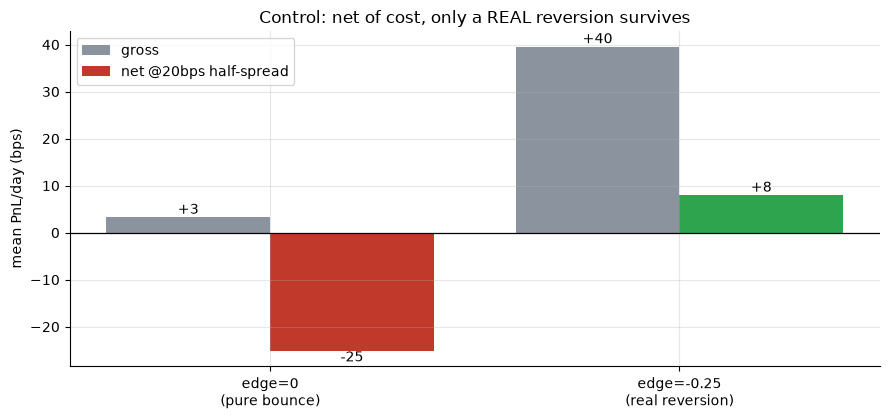

edge=+0.00: gross=+3.31bps(t=7.5)  net=-25.13bps(t=-56.9, Sharpe=-14.27)
edge=-0.25: gross=+39.58bps(t=89.0)  net=+8.01bps(t=18.0, Sharpe=4.51)


In [5]:
res = []
for edge in (0.0, -0.25):
    P = syn_panel(spread=0.004, edge=edge)
    g = st.summarize_book(P, 0.0); n = st.summarize_book(P, 0.002)
    res.append((edge, g['mean_bps'], g['t'], n['mean_bps'], n['t'], n['sharpe']))
labels = ['edge=0\n(pure bounce)', 'edge=-0.25\n(real reversion)']
x = np.arange(2); gv = [r[1] for r in res]; nv = [r[3] for r in res]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x-.2, gv, .4, color=GREY, label='gross')
ax.bar(x+.2, nv, .4, color=[RED if v<0 else GREEN for v in nv], label='net @20bps half-spread')
ax.axhline(0, c='k', lw=.9); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('mean PnL/day (bps)'); ax.set_title('Control: net of cost, only a REAL reversion survives'); ax.legend()
for i,(g_,n_) in enumerate(zip(gv,nv)):
    ax.annotate(f'{g_:+.0f}',(i-.2,g_),ha='center',va='bottom')
    ax.annotate(f'{n_:+.0f}',(i+.2,n_),ha='center',va='bottom' if n_>0 else 'top')
plt.tight_layout(); plt.show()
for e,g_,gt,n_,nt,sh in res:
    print(f'edge={e:+.2f}: gross={g_:+.2f}bps(t={gt:.1f})  net={n_:+.2f}bps(t={nt:.1f}, Sharpe={sh:.2f})')

> 💡 In plain words: with **no** real edge the book is gross **+3.3 bps** (t=8) yet net **-25.1 bps** (Sharpe -14.3) — the spread eats a signal that was never there. Only the planted **−0.25** reversion stays net-positive (**+8.0 bps**, Sharpe 4.5). The real small-cap tape behaves like the **first** column. The sample is the verdict.

## 5 · The verdict

- **Signal `WEAK`** — gross reversal Sharpe **1.20** (*t* = **5.47**), lag-1 autocorr **-0.065**: not noise. But Roll's estimator reads a **109 bps** spread from the same cov₁, and the control reproduces the entire gross signal from a *pure bounce* with zero efficient-price reversion. A real statistic that is a **microstructure artefact**, not a price forecast ⇒ WEAK, not REAL (survivorship tilts the gross number **up**, never down).
- **Tradability `MIRAGE`** — break-even round-trip **6.9 bps** vs an implied **109 bps** (**~16×**). Net @ 10 bps round-trip: Sharpe **-0.53**, **-2.2 bps/day**. No capacity, no deployable edge.
- **Free lunch? `BUSTED`** — a close-to-close backtest is *credited* the bounce it trades against and never *charged* it; the gross 'edge' is precisely $-(s/2)^2$. Short-horizon "mean reversion" is, in large part, the **bid-ask bounce in disguise** — Roll (1984).

## 6 · Could you trade it? — the capacity curve

The operational truth in one picture: net Sharpe as a function of the round-trip spread you actually pay. The break-even is a knife-edge far to the left of where real small-cap spreads live.

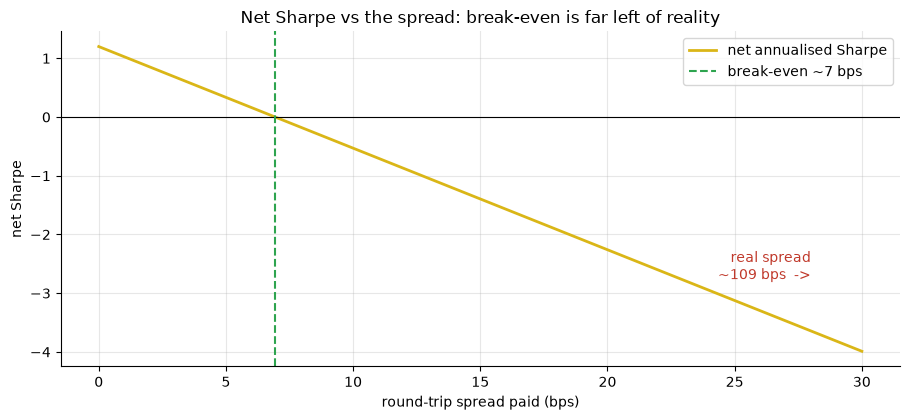

net Sharpe is positive only below ~7 bps round-trip; the real spread is ~109 bps.


In [6]:
rounds = np.linspace(0, 30, 31)            # round-trip spread in bps
if HAVE_REAL:
    sh = [st.book_sharpe(RET, (rt/2)/1e4) for rt in rounds]   # Sharpe only (no bootstrap)
    be_round = R['be_round_bps']; roll_sp = st.avg_roll_spread(RET)*1e4
else:
    g = R['book'][0][3]; slope = (R['book'][2][3]-g)/20.0
    sh = [g + slope*(rt/2) for rt in rounds]; be_round = R['be_round_bps']; roll_sp = R['roll_spread_bps']
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.plot(rounds, sh, c=AMBER, lw=2, label='net annualised Sharpe')
ax.axhline(0, c='k', lw=.8)
ax.axvline(be_round, c=GREEN, ls='--', label=f'break-even ~{be_round:.0f} bps')
ax.annotate(f'real spread\n~{roll_sp:.0f} bps  ->', xy=(28, ax.get_ylim()[0]*0.6),
            ha='right', va='center', color=RED, fontsize=10)
ax.set_xlabel('round-trip spread paid (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('Net Sharpe vs the spread: break-even is far left of reality'); ax.legend()
plt.tight_layout(); plt.show()
print(f'net Sharpe is positive only below ~{be_round:.0f} bps round-trip; the real spread is ~{roll_sp:.0f} bps.')

> 💡 In plain words: net Sharpe is positive only in a sliver below the break-even spread; real small-cap round-trips sit **far** to the right, deep in negative territory. There is no execution venue, no sizing, no patience that moves the real spread left of break-even — **the reversion you'd harvest *is* the spread you'd pay.** That identity, not a weak *t*-stat, is why the strategy cannot exist. The thing that makes the chart pretty is the thing that makes it untradable.

## 7 · Going further

- **The lower-frequency cousin.** [Study 329 — One-Month-Reversal](../../329-one-month-reversal/): the monthly reversal premium, where the bounce is a smaller share of the move — does the edge survive there, or is it the same trap with a longer holding period?
- **The illiquidity it lives in.** [Study 140 — Amihud-Illiquidity](../../140-amihud-illiquidity/): short-term reversal concentrates in illiquid names *because* that's where the bounce is biggest — the two are the same phenomenon viewed from different sides.
- **Better spread estimates.** Replace Roll's estimator with Corwin-Schultz (high-low) or Abdi-Ranaldo (close-high-low), or true TAQ quotes if you have them; the implied spread moves a little, the **16×** gap does not.

*The reproducible core is offline and deterministic (the Roll model); the effective spread is an explicit Roll-estimator proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*